In [1]:
# importer les librairies

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore") 


In [2]:
# charger les 2 datasets
df_raw = pd.read_csv("../data/raw/healthcare-dataset-stroke-data.csv")
df_processed = pd.read_csv("../data/processed/healthcare_stroke_dataset_clean.csv")

In [3]:
df_raw.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df_processed.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Nous allons faire une première exploration de notre dataset raw

In [5]:
df_raw.shape

(5110, 12)

In [6]:
df_raw.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [7]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


Nous observons des valeurs manquantes dans la variable bmi

In [8]:
# vérification des données manquantes
df_raw.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [9]:
df_raw.isnull().sum()/len(df_raw)*100

id                   0.000000
gender               0.000000
age                  0.000000
hypertension         0.000000
heart_disease        0.000000
ever_married         0.000000
work_type            0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
bmi                  3.933464
smoking_status       0.000000
stroke               0.000000
dtype: float64

La variable "bmi" comporte 201 données manquantes, soit 3,93%.

In [21]:
# vérifions s'il y'a des doublons
df_raw.duplicated().sum()

np.int64(0)

In [10]:
# statistiques des variables numériques
df_raw.describe().round(2)

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.00,5110.00,5110.0,5110.00,5110.00,4909.00,5110.00
mean,36517.83,43.23,0.1,0.05,106.15,28.89,0.05
std,21161.72,22.61,0.3,0.23,45.28,7.85,0.22
min,67.00,0.08,0.0,0.00,55.12,10.30,0.00
25%,17741.25,25.00,0.0,0.00,77.24,23.50,0.00
50%,36932.00,45.00,0.0,0.00,91.88,28.10,0.00
75%,54682.00,61.00,0.0,0.00,114.09,33.10,0.00
max,72940.00,82.00,1.0,1.00,271.74,97.60,1.00


In [11]:
# statistique des variables catégorielles
df_raw.describe(include=object)

,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


Comme notre objectif est la prédiction d'un AVC, notre variable cible ici est "stroke"

In [19]:
# Pour chaque variable de type objet, nous allons observer les catégories de chaque variable
for col in df_raw.select_dtypes(include="object"):
    print("\n", col )
    print(df_raw[col].value_counts())


 gender
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

 ever_married
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

 work_type
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

 Residence_type
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

 smoking_status
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


### Analyse de la variable cible

In [ ]:
# concernant la variable cible
df_raw["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

Cela nous montrele nombre de personnes qui :
ont eu un AVC (1) : 249
n'ont pas eu d'AVC (0): 4861

In [20]:
# ce qui représente en pourcentage:
(df_raw["stroke"].value_counts(normalize=True)*100).round(2)

stroke
0    95.13
1     4.87
Name: proportion, dtype: float64

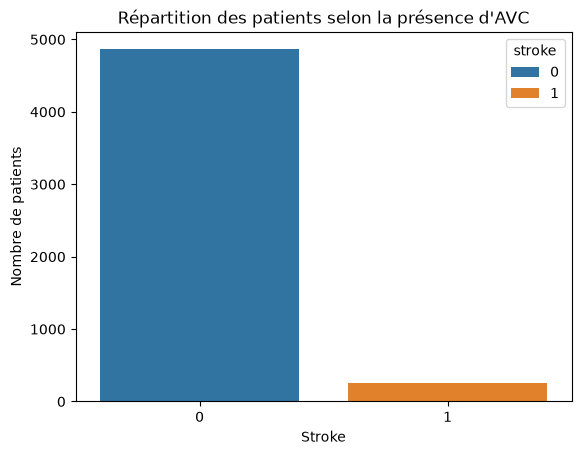

In [24]:
plt.Figure(figsize=(6,4))
sns.countplot(
    data=df_raw,
    x= "stroke",
    hue="stroke"
)
plt.title("Répartition des patients selon la présence d'AVC")
plt.xlabel("Stroke")
plt.ylabel("Nombre de patients")

plt.show()

La variable cible est fortement déséquilibrée. Les patients sans AVC représentent environ 95 % des observations contre seulement 5 % pour les patients ayant subi un AVC. Ce déséquilibre devra être pris en compte lors de l'entraînement des modèles afin d'éviter qu'ils privilégient systématiquement la classe majoritaire.

### Nous allons identifier nos variables afin de définir ce que nous en ferons:

In [27]:
variables = pd.DataFrame({"Variables": df_raw.columns,
              "Types": df_raw.dtypes.values})

variables

,Variables,Types
0,id,int64
1,gender,str
2,age,float64
3,hypertension,int64
4,heart_disease,int64
5,ever_married,str
6,work_type,str
7,Residence_type,str
8,avg_glucose_level,float64
9,bmi,float64


 Variable          | Type             | Prétraitement ML 
 ----------------- | ---------------- | ---------------- 
 age               | Numérique        | Standardisation  
 avg_glucose_level | Numérique        | Standardisation  
 bmi               | Numérique        | Standardisation  
 gender            | Catégorielle     | Encodage         
 ever_married      | Binaire (Yes/No) | Encodage         
 work_type         | Catégorielle     | Encodage         
 Residence_type    | Binaire          | Encodage         
 smoking_status    | Catégorielle     | Encodage         
 hypertension      | Binaire (0/1)    | Aucun            
 heart_disease     | Binaire (0/1)    | Aucun            
 stroke            | Variable cible   | —                


Ce tableau me sera utile dans le notebook 02_preprocessing, Car elle me permet de savoir

quelles colonnes encoder, 
lesquelles standardiser,
lesquelles laisser telles quelles.

### Nous allons vérifier les corrélations entre les variables pour comprendre les relations entre les variables numériques.

In [28]:
df_numeric = df_raw.select_dtypes(include="number")

corr_num = df_numeric.corr()
corr_num

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
id,1.000000,0.003538,0.003550,-0.001296,0.001092,0.003084,0.006388
age,0.003538,1.000000,0.276398,0.263796,0.238171,0.333398,0.245257
hypertension,0.003550,0.276398,1.000000,0.108306,0.174474,0.167811,0.127904
heart_disease,-0.001296,0.263796,0.108306,1.000000,0.161857,0.041357,0.134914
avg_glucose_level,0.001092,0.238171,0.174474,0.161857,1.000000,0.175502,0.131945
bmi,0.003084,0.333398,0.167811,0.041357,0.175502,1.000000,0.042374
stroke,0.006388,0.245257,0.127904,0.134914,0.131945,0.042374,1.000000


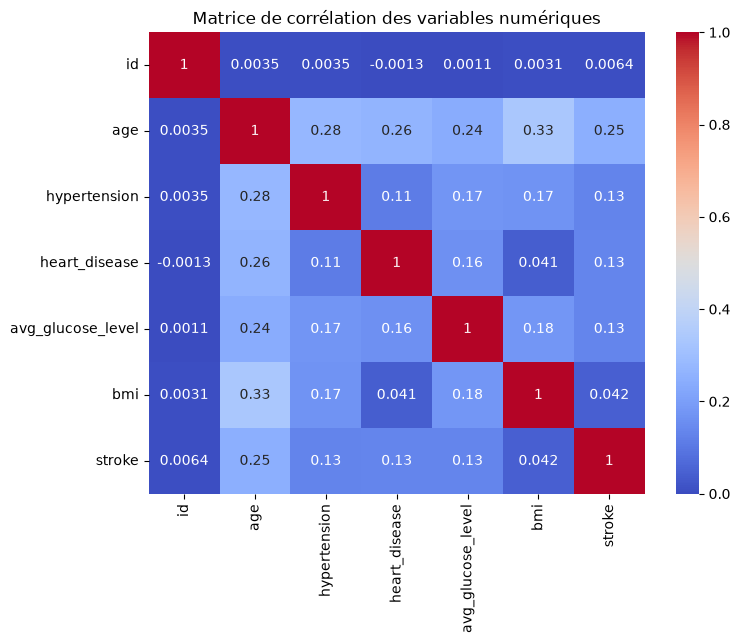

In [34]:
# nous allons observer cela grâce à un heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_num,
    annot=True,
    cmap="coolwarm"
)

plt.title("Matrice de corrélation des variables numériques")

plt.show()

### Nous allons comparer notre dataset raw avec notre dataset clean processed

In [14]:
print (f" df_raws comportent les colonnes : {df_raw.columns}")

print ("########################################################")
print ("########################################################")
print ("########################################################")

print (f" df_processed comportent les colonnes : {df_processed.columns}")

 df_raws comportent les colonnes : Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')
########################################################
########################################################
########################################################
 df_processed comportent les colonnes : Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')


on observe que la conne "id" a été supprimé dans df_processed